In [2]:
using CovidSim_ilm

┌ Info: Precompiling CovidSim_ilm [top-level]
└ @ Base loading.jl:1317


In [168]:
using StatsBase
using TypedTables
using BenchmarkTools
using Distributions
using YAML
using PrettyPrint
using Plots
using OffsetArrays

In [4]:
cd(joinpath(homedir(),"Dropbox/Covid Modeling/Covid-ILM/source"))

In [144]:
newtrans = CovidSim_ilm.setup_dt("/Users/lewis/Dropbox/Covid Modeling/Covid-ILM/parameters/default_covid/default_transition_array.yml")

Dict{agegrp, Dict{Int64, Dict{Symbol, Any}}} with 5 entries:
  age20_39 => Dict(5=>Dict(:transition=>[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; …
  age40_59 => Dict(5=>Dict(:transition=>[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; …
  age60_79 => Dict(5=>Dict(:transition=>[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; …
  age80_up => Dict(5=>Dict(:transition=>[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; …
  age0_19  => Dict(5=>Dict(:transition=>[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; …

In [205]:
T = typeof(newtrans[age80_up][1][:transition])

OffsetMatrix{Float64, Matrix{Float64}} (alias for OffsetArray{Float64, 2, Array{Float64, 2}})

In [206]:
transarr = Dict{Int, T}()

Dict{Int64, OffsetMatrix{Float64, Matrix{Float64}}}()

In [207]:
agesel=age80_up
for i in 1:5
    transarr[i] = newtrans[agesel][i][:transition]
end

In [214]:
transarr[1]'

6×4 adjoint(OffsetArray(::Matrix{Float64}, 5:8, 3:8)) with eltype Float64 with indices 3:8×5:8:
 0.0  0.0  0.0  0.0
 0.1  0.0  0.0  0.0
 0.5  0.0  0.0  0.0
 0.4  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0

In [211]:
transarr[2]

4×6 OffsetArray(::Matrix{Float64}, 5:8, 3:8) with eltype Float64 with indices 5:8×3:8:
 0.5  0.0  0.0  0.0  0.5  0.0
 0.0  0.0  0.4  0.6  0.0  0.0
 0.0  0.0  0.0  0.6  0.4  0.0
 0.0  0.0  0.0  0.0  0.0  0.0

In [210]:
vcat([0.0 0.0 0.0 0.0 0.0 0.0],transarr[1], [0.0 0.0 0.0 0.0 0.0 0.0])' .* vcat([1.0 0.0 0.0 0.0 0.0 0.0],transarr[2], [0.0 0.0 0.0 0.0 0.0 1.0])

6×6 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0

In [169]:
trvec = OffsetArray(zeros(6), 3:8)

6-element OffsetArray(::Vector{Float64}, 3:8) with eltype Float64 with indices 3:8:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [170]:
trvec[:] = transarr[severe,:]

6-element OffsetArray(::Vector{Float64}, 3:8) with eltype Float64 with indices 3:8:
 0.676
 0.0
 0.0
 0.0
 0.0
 0.324

In [172]:
CovidSim_ilm.categorical_sim(transarr[severe,:])

1

In [183]:
CovidSim_ilm.mapshift2cond

Dict{shift, Enum{Int32}} with 6 entries:
  tosevere  => severe
  torecover => recovered
  tomild    => mild
  tosick    => sick
  todead    => dead
  tonil     => nil

In [185]:
CovidSim_ilm.mapshift2cond[CovidSim_ilm.tosevere]

severe::condition = 8

In [148]:
size(first(first(newtrans)[end])[end][:transition], 2)

6

# Test setup and population matrix

In [149]:
# set locale and number of days
locale = 38015
ndays = 180

180

# Create a seed case

In [150]:
seed_1_6 = seed_case_gen(1, [0,3,3,0,0], 1, mild, :base, agegrps)

(::CovidSim_ilm.var"#runcase#260"{CovidSim_ilm.var"#runcase#259#261"{Int64, Vector{Int64}, Int64, condition, Symbol, NTuple{5, agegrp}}}) (generic function with 1 method)

# Run a simulation

In [197]:
result_dict, series = run_a_sim(ndays, locale; 
    dovax=false, 
    dovariant=true,
    paramdir = "../parameters",
    geofilename = "../data/geo2data.csv", 
    socialfilename = "socialparams.yml",
    vaccinefilename = "vaccines.yml",
    variantsfilename = "variants.yml",
    showr0=false, 
    silent=true, 
    runcases=[seed_1_6]);

*** seed day 1: 6 mild to 38015
(idxtime, sprtime, trtime, histtime) = (0.066207709, 0.344330954, 0.2531722390000001, 0.2161566089999999)


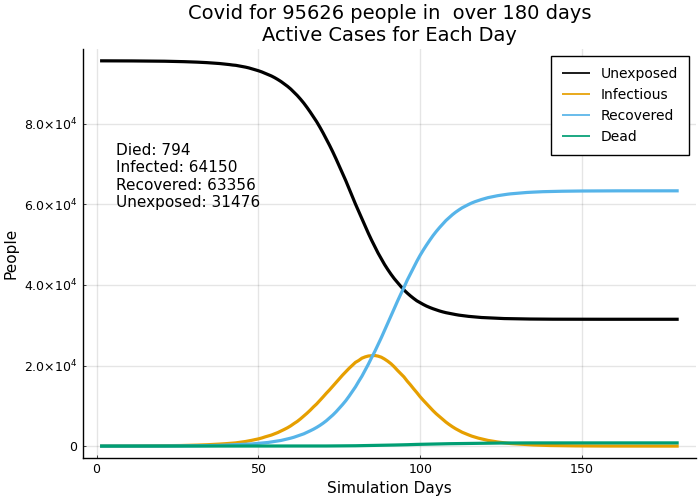

In [188]:
cumplot(series, locale)

In [127]:
shift

Enum shift:
torecover = 3
todead = 4
tonil = 5
tomild = 6
tosick = 7
tosevere = 8